# Two-axis epoch × time-of-flight grid

Two-parameter cartesian product over launch epoch (`Sat.Epoch`) and time-of-flight (a script-level `Variable TOF` that drives the `Propagate` stopping condition). The per-run scalar — distance from the final inertial position to a fixed reference point — is reshaped into a 2D matrix and contoured.

This is the smallest end-to-end exercise of the *two-axis* surface: the same [`sweep()`](https://astro-tools.github.io/gmat-sweep/api/#gmat_sweep.sweep) call accepts a grid with multiple keys; the cartesian product is expanded internally and dispatched in parallel.

The arrival metric here is contrived (a fixed inertial point picked to make the contour interesting, not a real target). The point is the 2D-sweep machinery, not the astrodynamics.

**Prerequisites.** A local GMAT install (R2026a is the primary development target) and `pip install gmat-sweep[examples]` for the matplotlib dependency.

## Set up the run

Resolve the GMAT install once and confirm the script that ships next to this notebook is where we expect it. The script declares `Sat.Epoch` and `Variable TOF` as the two fields the notebook will override per run.

In [1]:
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gmat_run import locate_gmat

from gmat_sweep import Manifest, sweep

install = locate_gmat()
script_path = Path("transfer_porkchop.script").resolve()

print(f"GMAT version: {install.version}")
print(f"Script:       {script_path.name}")
print(f"Exists:       {script_path.exists()}")

GMAT version: R2026a
Script:       transfer_porkchop.script
Exists:       True


## Define the two grid axes

Six launch epochs spaced four hours apart over the first day of 2026, and six time-of-flight values from one to four hours. The cartesian product is 36 runs.

`Sat.Epoch` is set by string (GMAT's wire format is `'DD Mmm YYYY HH:MM:SS.sss'`); `TOF.Value` reads and writes through the same dotted-path setter as any other field.

In [2]:
launch_offsets_h = np.array([0, 4, 8, 12, 16, 20])
epoch_base = pd.Timestamp("2026-01-01 00:00:00")
epochs = [
    (epoch_base + pd.Timedelta(hours=int(h))).strftime("%d %b %Y %H:%M:%S.000")
    for h in launch_offsets_h
]
tof_hours = np.array([1.0, 1.5, 2.0, 2.5, 3.0, 4.0])
tof_seconds = (tof_hours * 3600.0).tolist()

for epoch in epochs:
    print(epoch)
print(f"\nTOF (hours): {tof_hours.tolist()}")
print(f"\nTotal runs:  {len(epochs) * len(tof_seconds)}")

01 Jan 2026 00:00:00.000
01 Jan 2026 04:00:00.000
01 Jan 2026 08:00:00.000
01 Jan 2026 12:00:00.000
01 Jan 2026 16:00:00.000
01 Jan 2026 20:00:00.000

TOF (hours): [1.0, 1.5, 2.0, 2.5, 3.0, 4.0]

Total runs:  36


## Run the sweep

Pass `out=` so the per-run Parquet files and the JSON Lines manifest survive past the call — we'll reload the manifest below to map each `run_id` back to its `(epoch, TOF)` cell. The default `out=None` would tie everything to the DataFrame's lifetime.

In [3]:
tmpdir = tempfile.TemporaryDirectory(prefix="epoch-arrival-grid-")
out_dir = Path(tmpdir.name)

df = sweep(
    script_path,
    grid={"Sat.Epoch": epochs, "TOF.Value": tof_seconds},
    out=out_dir,
    progress=False,
)
df["__status"].value_counts()

__status
ok    918
Name: count, dtype: int64

## Compute arrival miss distance per run

The per-run scalar of interest is the Euclidean distance from the spacecraft's final inertial position to a fixed reference point. The DataFrame is indexed by `(run_id, time)` so we group by `run_id` and take the last row per group; the final timestep is the propagation end-state.

The target point is picked off the orbit's reachable region so the contour shows interesting structure — there is no orbital-mechanics significance.

In [4]:
TARGET = np.array([10000.0, -3000.0, 0.0])

final = df.groupby(level="run_id").last()
final_pos = final[["Sat.X", "Sat.Y", "Sat.Z"]].to_numpy()
miss_km = np.linalg.norm(final_pos - TARGET, axis=1)

miss = pd.Series(miss_km, index=final.index, name="miss_km")
miss.head()

run_id
0    24038.041026
1    26811.468981
2    26532.436975
3    23279.149050
4    16260.474932
Name: miss_km, dtype: float64

## Reshape into a 2D matrix

[`Manifest.load`](https://astro-tools.github.io/gmat-sweep/api/#gmat_sweep.Manifest.load) reads back the JSON Lines manifest the sweep wrote. Each entry's `overrides` dict carries the parameters applied to that run — using it to rebuild the `(epoch, TOF)` index avoids relying on the (deterministic but undocumented at the call site) `run_id` ordering convention.

In [5]:
manifest = Manifest.load(out_dir / "manifest.jsonl")

by_cell = pd.DataFrame(
    {
        "epoch": [e.overrides["Sat.Epoch"] for e in manifest.entries],
        "tof_h": [e.overrides["TOF.Value"] / 3600.0 for e in manifest.entries],
        "miss_km": miss.loc[[e.run_id for e in manifest.entries]].to_numpy(),
    }
)

miss_grid = by_cell.pivot(index="epoch", columns="tof_h", values="miss_km")
miss_grid

tof_h,1.0,1.5,2.0,2.5,3.0,4.0
epoch,,,,,,
01 Jan 2026 00:00:00.000,24038.041026,26811.468981,26532.436975,23279.14905,16260.474932,14163.058079
01 Jan 2026 04:00:00.000,24038.041026,26811.468981,26532.436975,23279.14905,16260.474932,14163.058079
01 Jan 2026 08:00:00.000,24038.041026,26811.468981,26532.436975,23279.14905,16260.474932,14163.058079
01 Jan 2026 12:00:00.000,24038.041026,26811.468981,26532.436975,23279.14905,16260.474932,14163.058079
01 Jan 2026 16:00:00.000,24038.041026,26811.468981,26532.436975,23279.14905,16260.474932,14163.058079
01 Jan 2026 20:00:00.000,24038.041026,26811.468981,26532.436975,23279.14905,16260.474932,14163.058079


## Contour

The contour shows how the arrival miss distance varies across the launch-epoch × time-of-flight grid. The dark band is the locus of `(epoch, TOF)` pairs where the spacecraft's final position is closest to the synthetic target.

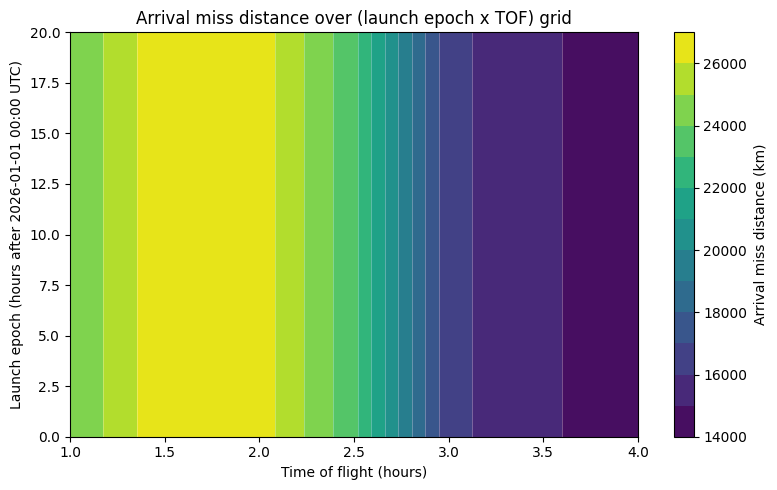

In [6]:
Z = miss_grid.to_numpy()

fig, ax = plt.subplots(figsize=(8, 5))
cf = ax.contourf(tof_hours, launch_offsets_h, Z, levels=12, cmap="viridis")
ax.contour(tof_hours, launch_offsets_h, Z, levels=12, colors="white", linewidths=0.4, alpha=0.5)
fig.colorbar(cf, ax=ax, label="Arrival miss distance (km)")
ax.set_xlabel("Time of flight (hours)")
ax.set_ylabel("Launch epoch (hours after 2026-01-01 00:00 UTC)")
ax.set_title("Arrival miss distance over (launch epoch x TOF) grid")
fig.tight_layout()
plt.show()

## Heatmap via `sweep_heatmap`

[`sweep_heatmap`](https://astro-tools.github.io/gmat-sweep/api/#gmat_sweep.plotting.sweep_heatmap) reads a numeric per-run scalar over the two grid axes, pivots into the matching 2-D matrix, and renders the heatmap in one call. Both axes must resolve to numeric values; `Sat.Epoch` is set by GMAT's string wire format, so attach the numeric `launch_offsets_h` proxy back onto `df` first. The metric is the same `miss_km` reduction the contour above uses.

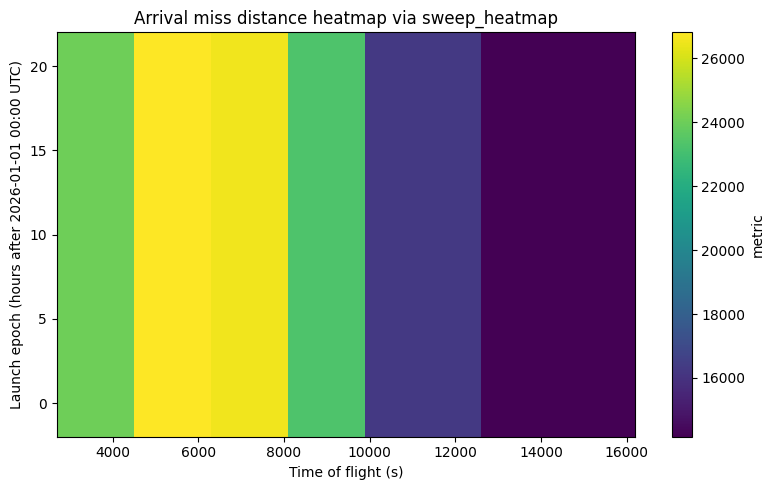

In [7]:
from gmat_sweep.plotting import sweep_heatmap

epoch_to_h = dict(zip(epochs, launch_offsets_h.tolist(), strict=True))
df["epoch_h"] = df.index.get_level_values("run_id").map(
    {e.run_id: epoch_to_h[e.overrides["Sat.Epoch"]] for e in manifest.entries}
)
df["TOF.Value"] = df.index.get_level_values("run_id").map(
    {e.run_id: e.overrides["TOF.Value"] for e in manifest.entries}
)


def miss_per_run_series(df_in):
    final = df_in.groupby(level="run_id").last()
    final_pos = final[["Sat.X", "Sat.Y", "Sat.Z"]].to_numpy()
    return pd.Series(np.linalg.norm(final_pos - TARGET, axis=1), index=final.index, name="miss_km")


fig, ax = plt.subplots(figsize=(8, 5))
sweep_heatmap(df, "TOF.Value", "epoch_h", miss_per_run_series, ax=ax)
ax.set_xlabel("Time of flight (s)")
ax.set_ylabel("Launch epoch (hours after 2026-01-01 00:00 UTC)")
ax.set_title("Arrival miss distance heatmap via sweep_heatmap")
fig.tight_layout()
plt.show()

## Where to next

- **Survive a kill mid-sweep.** [Notebook 03](https://astro-tools.github.io/gmat-sweep/examples/03_killed_sweep_recovery/) walks through interrupting a sweep with `SIGINT` and reading the partial manifest back from disk.
- **Real porkchop plots** require Lambert targeting and a moving target body — gmat-sweep is a parallel evaluator, not an optimiser. The 2D-grid mechanism shown here is the building block; the targeting layer that turns it into a true porkchop is out of scope (see [`CONTRIBUTING.md`](https://github.com/astro-tools/gmat-sweep/blob/main/CONTRIBUTING.md#scope-discipline)).
- **Manifest schema.** [Manifest schema](https://astro-tools.github.io/gmat-sweep/manifest-schema/) documents every field the JSON Lines records carry.